In [1]:
# LIME Explanations 
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
import warnings
warnings.filterwarnings('ignore')

DATA_PATH   = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\data"
MODEL_PATH  = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\models"
RESULT_PATH = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\results"

# Load everything
print("Loading model and data...")
rf            = joblib.load(f"{MODEL_PATH}\\random_forest.pkl")
le            = joblib.load(f"{DATA_PATH}\\label_encoder.pkl")
feature_names = joblib.load(f"{DATA_PATH}\\feature_names.pkl")
X_train_sm    = joblib.load(f"{DATA_PATH}\\X_train_sm.pkl")
X_test        = joblib.load(f"{DATA_PATH}\\X_test.pkl")
y_test        = joblib.load(f"{DATA_PATH}\\y_test.pkl")
X_sample      = joblib.load(f"{DATA_PATH}\\X_sample.pkl")
y_sample      = joblib.load(f"{DATA_PATH}\\y_sample.pkl")

print(f"All data loaded successfully")
print(f"Classes: {list(le.classes_)}")

# Create LIME explainer
explainer = LimeTabularExplainer(
    training_data  = X_train_sm,
    feature_names  = feature_names,
    class_names    = list(le.classes_),
    mode           = 'classification',
    random_state   = 42
)
print(f"\nLIME explainer created successfully")
print(f"Training data shape: {X_train_sm.shape}")

Loading model and data...
All data loaded successfully
Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']

LIME explainer created successfully
Training data shape: (2020061, 47)


PortScan instances in sample: 50
True label     : PortScan
Predicted label: PortScan

Generating LIME explanation...
LIME explanation generated in 0.1 seconds

Top 10 features for PortScan prediction:
Feature                              LIME Weight
--------------------------------------------------
min_seg_size_forward > 1.00             0.0495  → Attack
0.00 < PSH Flag Count <= 1.00           0.0225  → Attack
Total Length of Fwd Packets <= 0.00     0.0213  → Attack
0.00 < Init_Win_bytes_backward <= 0.00     0.0171  → Attack
Fwd Packet Length Max <= 0.00           0.0168  → Attack
Fwd Packet Length Mean <= 0.00          0.0133  → Attack
Init_Win_bytes_forward > 0.13           0.0130  → Attack
0.00 < Flow IAT Min <= 0.00             0.0110  → Attack
Total Fwd Packets <= 0.00               0.0104  → Attack
RST Flag Count <= 0.00                  0.0029  → Attack


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


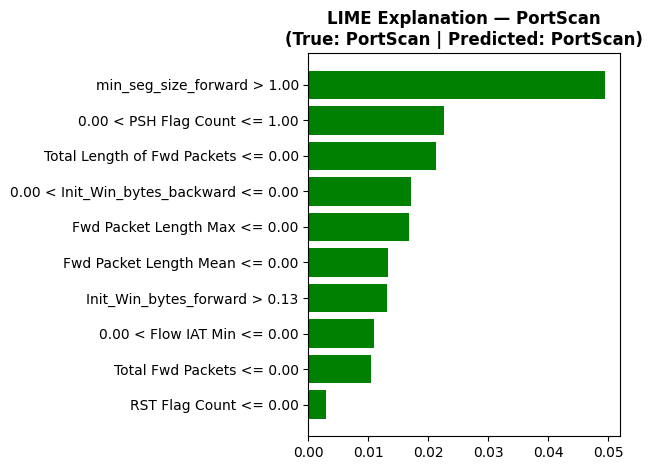


LIME PortScan plot saved


In [2]:
# LIME — PortScan Instance 
import time

# Find a PortScan instance (class index 10)
portscan_idx = np.where(y_sample == 10)[0]
print(f"PortScan instances in sample: {len(portscan_idx)}")

# Pick the first one
instance_idx = portscan_idx[0]
instance     = X_sample[instance_idx]
true_label   = le.classes_[y_sample[instance_idx]]
pred_label   = le.classes_[rf.predict([instance])[0]]

print(f"True label     : {true_label}")
print(f"Predicted label: {pred_label}")

# Generate LIME explanation
print("\nGenerating LIME explanation...")
start = time.time()

lime_exp = explainer.explain_instance(
    data_row       = instance,
    predict_fn     = rf.predict_proba,
    num_features   = 10,
    num_samples    = 1000,
    labels         = [10]  # PortScan class
)

elapsed = time.time() - start
print(f"LIME explanation generated in {elapsed:.1f} seconds")

# Show top features
print(f"\nTop 10 features for PortScan prediction:")
print(f"{'Feature':<35} {'LIME Weight':>12}")
print("-" * 50)
for feat, weight in lime_exp.as_list(label=10):
    direction = "→ Attack" if weight > 0 else "→ Benign"
    print(f"{feat:<35} {weight:>10.4f}  {direction}")

# Save LIME plot
fig = lime_exp.as_pyplot_figure(label=10)
plt.title(f'LIME Explanation — PortScan\n(True: {true_label} | Predicted: {pred_label})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{RESULT_PATH}\\lime_portscan.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nLIME PortScan plot saved")

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished



Generating LIME explanation for FTP-Patator...
Generated in 0.1 seconds
True: FTP-Patator | Predicted: FTP-Patator

Top 10 features:
Feature                              LIME Weight
--------------------------------------------------
Destination Port <= 0.00                0.0116  → Attack
Init_Win_bytes_forward > 0.13           0.0106  → Attack
Bwd Header Length > 0.99                0.0104  → Attack
Bwd IAT Total > 0.00                    0.0097  → Attack
act_data_pkt_fwd > 0.00                 0.0094  → Attack
0.00 < Fwd Packet Length Max <= 0.00     0.0093  → Attack
0.00 < Bwd Packets/s <= 0.00            0.0092  → Attack
Flow Duration > 0.04                    0.0075  → Attack
0.00 < Packet Length Variance <= 0.00     0.0072  → Attack
FIN Flag Count <= 0.00                  0.0071  → Attack


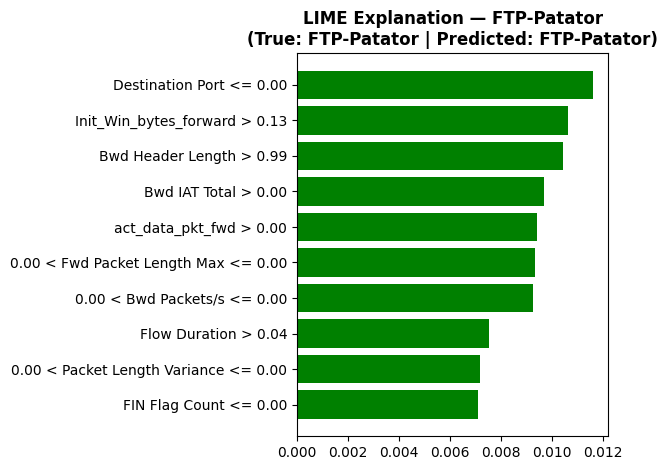

  Saved: lime_FTP_Patator.png

Generating LIME explanation for Bot...
Generated in 0.1 seconds
True: Bot | Predicted: Bot

Top 10 features:
Feature                              LIME Weight
--------------------------------------------------
Destination Port > 0.01                 0.0122  → Attack
0.00 < act_data_pkt_fwd <= 0.00         0.0117  → Attack
0.00 < Fwd IAT Std <= 0.01              0.0113  → Attack
Init_Win_bytes_backward > 0.00          0.0101  → Attack
Bwd IAT Std > 0.00                      0.0100  → Attack
Bwd IAT Min > 0.00                      0.0099  → Attack
0.00 < Total Fwd Packets <= 0.00        0.0095  → Attack
0.00 < Packet Length Mean <= 0.02       0.0092  → Attack
0.00 < Flow IAT Max <= 0.04             0.0087  → Attack
0.99 < Bwd Header Length <= 0.99        0.0087  → Attack


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


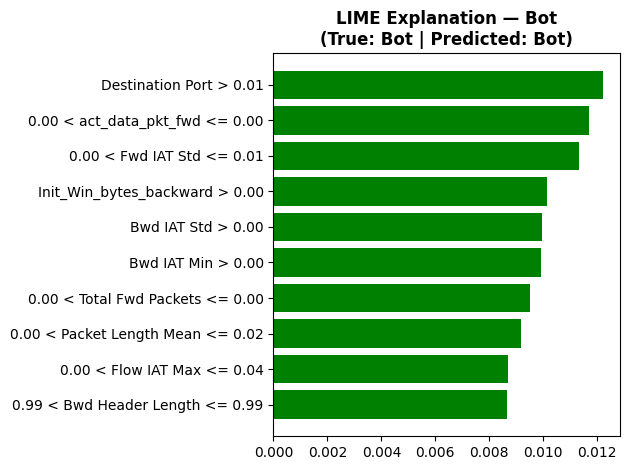

  Saved: lime_Bot.png

All LIME explanations complete!


In [3]:
# LIME — FTP-Patator and Bot
target_classes = {
    7 : 'FTP-Patator',
    1 : 'Bot'
}

for class_idx, class_name in target_classes.items():
    instances = np.where(y_sample == class_idx)[0]
    if len(instances) == 0:
        print(f"No {class_name} instances found in sample")
        continue

    instance     = X_sample[instances[0]]
    true_label   = le.classes_[y_sample[instances[0]]]
    pred_label   = le.classes_[rf.predict([instance])[0]]

    print(f"\nGenerating LIME explanation for {class_name}...")
    start = time.time()

    lime_exp = explainer.explain_instance(
        data_row     = instance,
        predict_fn   = rf.predict_proba,
        num_features = 10,
        num_samples  = 1000,
        labels       = [class_idx]
    )

    elapsed = time.time() - start
    print(f"Generated in {elapsed:.1f} seconds")
    print(f"True: {true_label} | Predicted: {pred_label}")

    print(f"\nTop 10 features:")
    print(f"{'Feature':<35} {'LIME Weight':>12}")
    print("-" * 50)
    for feat, weight in lime_exp.as_list(label=class_idx):
        direction = "→ Attack" if weight > 0 else "→ Benign"
        print(f"{feat:<35} {weight:>10.4f}  {direction}")

    fig = lime_exp.as_pyplot_figure(label=class_idx)
    plt.title(f'LIME Explanation — {class_name}\n(True: {true_label} | Predicted: {pred_label})',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    save_name = class_name.replace(' ', '_').replace('-', '_')
    plt.savefig(f"{RESULT_PATH}\\lime_{save_name}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: lime_{save_name}.png")

print("\nAll LIME explanations complete!")